<a href="https://colab.research.google.com/github/EdwardWendling/Biblioteca-Panada-Regress-o-Linear/blob/main/RID166360_Desafio07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Desafio 07: Modelo de análise das métricas RFV**


Fui contratado por uma empresa de e-commerce que está buscando entender melhor o comportamento de seus clientes para personalizar as suas campanhas de marketing.

Com base nesses dados, preciso agrupar os clientes em clusters com base em seu comportamento de compra. Isso irá permitir identificar padrões e características em comum entre os clientes, como:

•	Clientes que compram os mesmos produtos;

•	Clientes que possuem a mesma frequência de compras;

•	Clientes que gastam mais dinheiro em suas compras.


In [4]:
import pandas as pd

In [9]:
# Carregar o arquivo enviado
file_path = '/content/data.csv'

# Carregar o arquivo com outra codificação
data = pd.read_csv(file_path, encoding='latin1')

# Exibir as 5 primeiras linhas e informações básicas para verificar a estrutura dos dados
data.head(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


(  InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
       InvoiceDate  UnitPrice  CustomerID         Country  
 0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
 1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
 2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
 3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
 4  12/1/2010 8:26       3.39     17850.0  United Kingdom  ,
 None)

**Observações:**

- Existem valores nulos em Description e CustomerID.

- A coluna InvoiceDate precisa ser convertida para um formato datetime.

- As colunas InvoiceNo, StockCode e CustomerID devem ser tratadas como categorias.

- Dados como Quantity e UnitPrice serão úteis para calcular métricas de comportamento.

In [10]:
# Tratamento de valores nulos
# Substituir descrições nulas por "Unknown"
data['Description'] = data['Description'].fillna('Unknown')

In [11]:
# Remover registros onde o CustomerID está ausente (não é possível associar ao cliente)
data = data.dropna(subset=['CustomerID'])

In [12]:
# Ajustar o tipo de CustomerID para string (para tratá-lo como categórico)
data['CustomerID'] = data['CustomerID'].astype(str)

In [13]:
# Ajustar a conversão para lidar com datas em formatos variados
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')

In [14]:
# Verificar se ainda há valores nulos após a conversão
data['InvoiceDate'].isnull().sum()

0

**Etapa 01 -  Análise exploratória dos dados**

1.	Carregar a base de dados;
2.	Realizar uma descrição estatística dos dados;
3.	Visualizar as distribuições e identificar a relevância das colunas para a análise;
4.	Verificar a presença de dados nulos, duplicados, outliers e demais inconsistências nos dados.



In [15]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Visualizar as primeiras linhas do dataset
print("Primeiras linhas do dataset:")
print(data.head())

Primeiras linhas do dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice CustomerID         Country  
0 2010-12-01 08:26:00       2.55    17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39    17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75    17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39    17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39    17850.0  United Kingdom  


In [17]:
# Informações gerais do dataset
print("\nInformações do dataset:")
print(data.info())


Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB
None


In [18]:
# 2. Descrição Estatística dos Dados
print("\nDescrição estatística das colunas numéricas:")
print(data.describe())


Descrição estatística das colunas numéricas:
            Quantity                    InvoiceDate      UnitPrice
count  406829.000000                         406829  406829.000000
mean       12.061303  2011-07-10 16:30:57.879207424       3.460471
min    -80995.000000            2010-12-01 08:26:00       0.000000
25%         2.000000            2011-04-06 15:02:00       1.250000
50%         5.000000            2011-07-31 11:48:00       1.950000
75%        12.000000            2011-10-20 13:06:00       3.750000
max     80995.000000            2011-12-09 12:50:00   38970.000000
std       248.693370                            NaN      69.315162


Text(0.5, 1.0, 'Distribuição de Quantity')

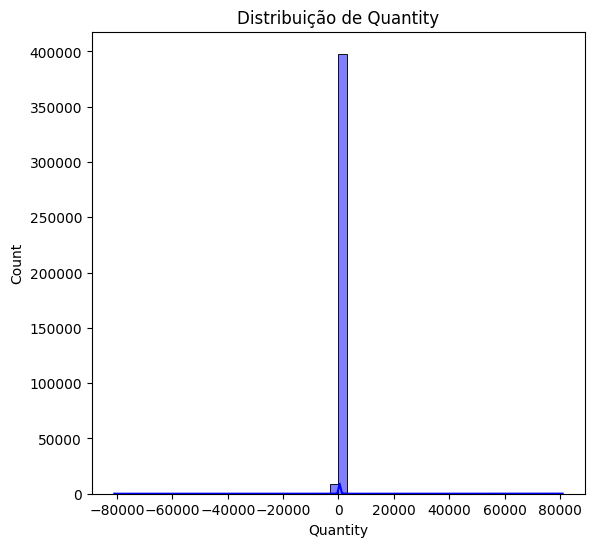

In [19]:
# 3. Visualização e Relevância das Colunas
# Histograma para 'Quantity' e 'UnitPrice'
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(data['Quantity'], bins=50, kde=True, color='blue')
plt.title('Distribuição de Quantity')

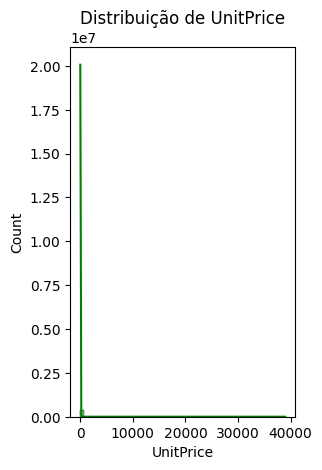

In [20]:
plt.subplot(1, 2, 2)
sns.histplot(data['UnitPrice'], bins=50, kde=True, color='green')
plt.title('Distribuição de UnitPrice')

plt.show()

In [21]:
# Verificar valores únicos em colunas importantes
print("\nValores únicos em colunas importantes:")
print("CustomerID:", data['CustomerID'].nunique())
print("StockCode:", data['StockCode'].nunique())


Valores únicos em colunas importantes:
CustomerID: 4372
StockCode: 3684


In [22]:
# 4. Verificação de Problemas nos Dados
# Verificar dados nulos
print("\nVerificação de valores nulos:")
print(data.isnull().sum())


Verificação de valores nulos:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [23]:
# Verificar duplicados
print("\nQuantidade de linhas duplicadas:", data.duplicated().sum())


Quantidade de linhas duplicadas: 5225


Text(0.5, 1.0, 'Outliers em Quantity')

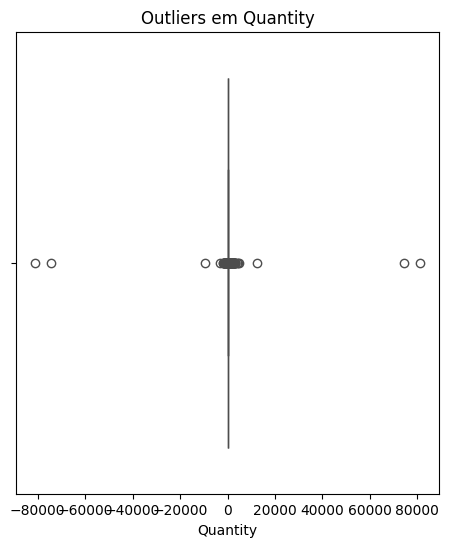

In [24]:
# Identificar outliers usando boxplots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x=data['Quantity'], color='orange')
plt.title('Outliers em Quantity')

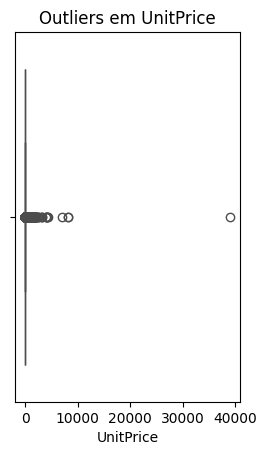

In [25]:
plt.subplot(1, 2, 2)
sns.boxplot(x=data['UnitPrice'], color='red')
plt.title('Outliers em UnitPrice')

plt.show()

In [26]:
# Ajustes sugeridos
# Tratar CustomerID e StockCode como categorias
data['CustomerID'] = data['CustomerID'].astype(str)
data['StockCode'] = data['StockCode'].astype(str)

In [27]:
# Converter InvoiceDate para formato datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], errors='coerce')

In [28]:
# Exibir informações após os ajustes
print("\nInformações após ajustes:")
print(data.info())


Informações após ajustes:
<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.9+ MB
None


**Etapa 02 - Pré-processamento dos dados**

Pré-processar os dados para preparar a base para o modelo de clusterização

1.	Realizar a normalização dos dados
2.	Fazer seleção das variáveis mais relevantes para o modelo
3.	Remover os dados nulos, duplicados, outliers e inconsistentes


In [29]:
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

In [30]:
# 1. Criar novas métricas
# Total gasto por transação
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

In [31]:
# Calcular recência, frequência e total gasto por cliente
now = datetime(2011, 12, 10)

# Definir data de referência para cálculo de recência
customer_data = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (now - x.max()).days,

# Recência
    'InvoiceNo': 'nunique',

# Frequência de compras
    'TotalPrice': 'sum'

# Total gasto
}).reset_index()

In [32]:
# Renomear colunas
customer_data.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("\nDados agregados por cliente (antes da normalização):")
print(customer_data.head())


Dados agregados por cliente (antes da normalização):
  CustomerID  Recency  Frequency  Monetary
0    12346.0      325          2      0.00
1    12347.0        2          7   4310.00
2    12348.0       75          4   1797.24
3    12349.0       18          1   1757.55
4    12350.0      310          1    334.40


In [33]:
# 2. Normalização dos Dados
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(customer_data[['Recency', 'Frequency', 'Monetary']])

# Criar um DataFrame normalizado
normalized_df = pd.DataFrame(normalized_data, columns=['Recency', 'Frequency', 'Monetary'])
normalized_df['CustomerID'] = customer_data['CustomerID']

print("\nDados normalizados:")
print(normalized_df.head())


Dados normalizados:
    Recency  Frequency  Monetary CustomerID
0  0.871314   0.004049  0.015109    12346.0
1  0.005362   0.024291  0.030297    12347.0
2  0.201072   0.012146  0.021442    12348.0
3  0.048257   0.000000  0.021303    12349.0
4  0.831099   0.000000  0.016288    12350.0


In [34]:
# 3. Remoção de Dados Problemáticos
# Remover duplicados (caso existam)
normalized_df = normalized_df.drop_duplicates()

# Verificar e tratar outliers usando o método IQR
Q1 = customer_data[['Recency', 'Frequency', 'Monetary']].quantile(0.25)
Q3 = customer_data[['Recency', 'Frequency', 'Monetary']].quantile(0.75)
IQR = Q3 - Q1

# Identificar limites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Manter apenas dados dentro dos limites
filtered_data = customer_data[~(
    (customer_data[['Recency', 'Frequency', 'Monetary']] < lower_bound) |
    (customer_data[['Recency', 'Frequency', 'Monetary']] > upper_bound)
).any(axis=1)]

print("\nDados após remoção de outliers:")
print(filtered_data.describe())


Dados após remoção de outliers:
           Recency    Frequency     Monetary
count  3686.000000  3686.000000  3686.000000
mean     91.300868     3.129409   825.608045
std      91.009757     2.398398   764.110200
min       0.000000     1.000000 -1592.490000
25%      21.000000     1.000000   271.512500
50%      56.000000     2.000000   570.430000
75%     145.000000     4.000000  1139.297500
max     333.000000    11.000000  3563.850000


**Etapa 03 - Selecione um algoritmo de clusterização**

Selecionar o algoritmo de clusterização mais adequado, determinar o número ideal de clusters e implementá-lo.




Utilizaremos o K-Means, pois é adequado para dados numéricos e contínuos como os que temos (Recency, Frequency, Monetary).

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

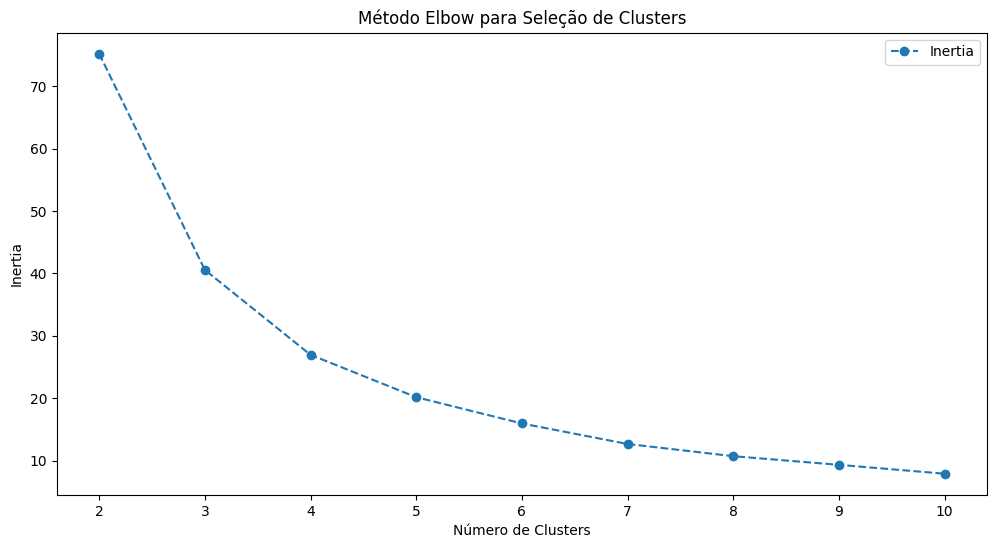

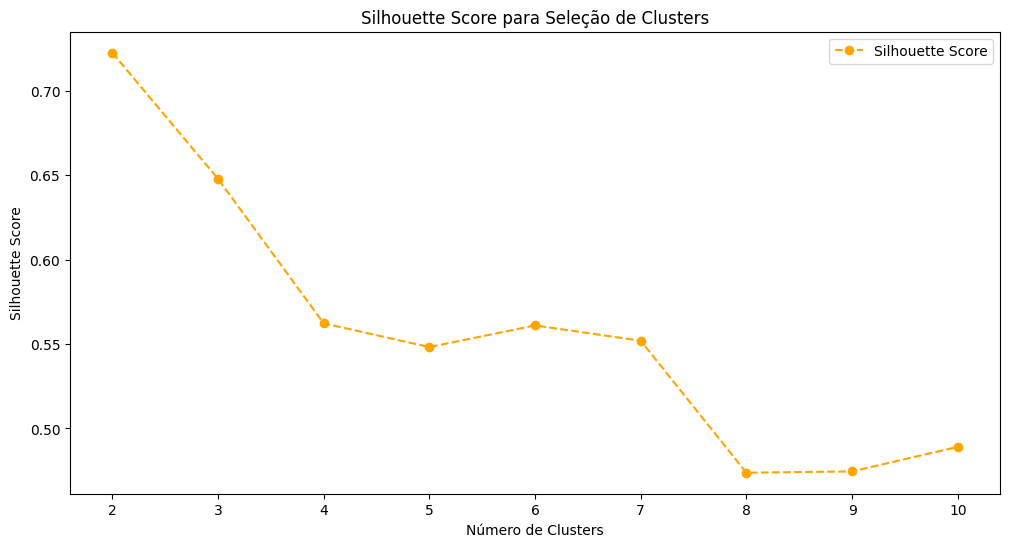

In [36]:
# 1. Determinar o número ideal de clusters usando o método Elbow
inertia = []
silhouette_scores = []
cluster_range = range(2, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(normalized_df[['Recency', 'Frequency', 'Monetary']])
    inertia.append(kmeans.inertia_)  # Soma dos erros quadrados dentro dos clusters
    silhouette_scores.append(silhouette_score(
        normalized_df[['Recency', 'Frequency', 'Monetary']], kmeans.labels_))

# Plot do Elbow Method
plt.figure(figsize=(12, 6))
plt.plot(cluster_range, inertia, marker='o', linestyle='--', label='Inertia')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')
plt.title('Método Elbow para Seleção de Clusters')
plt.legend()
plt.show()

# Plot do Silhouette Score
plt.figure(figsize=(12, 6))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='--', color='orange', label='Silhouette Score')
plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para Seleção de Clusters')
plt.legend()
plt.show()

In [37]:
# 2. Implementar K-Means com o número ideal de clusters
# Supondo que o número ideal encontrado seja 3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(normalized_df[['Recency', 'Frequency', 'Monetary']])
normalized_df['Cluster'] = kmeans.labels_

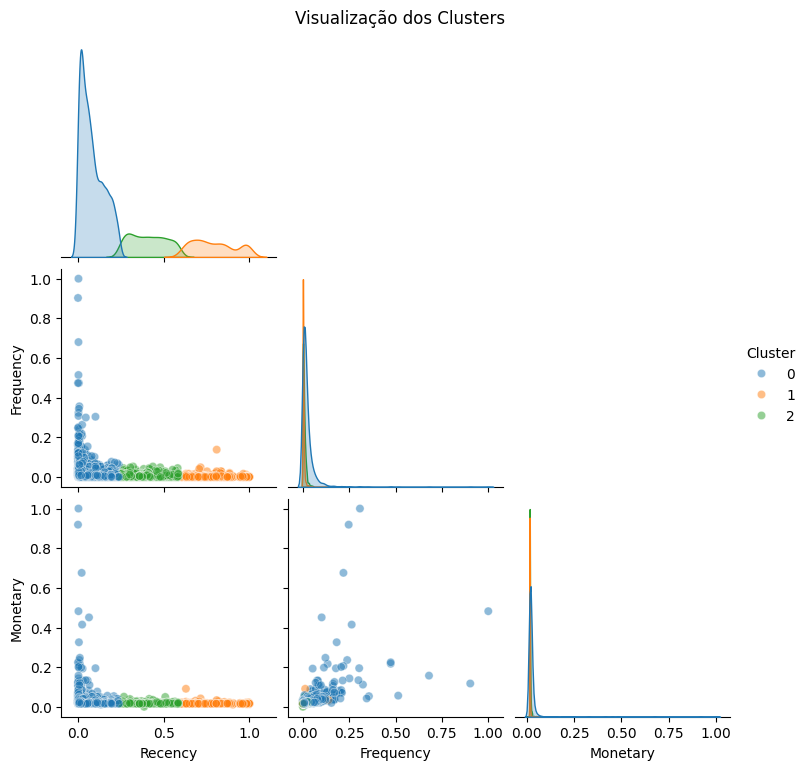

In [38]:
# 3. Visualização dos Clusters
sns.pairplot(normalized_df, hue='Cluster', diag_kind='kde', corner=True,
             plot_kws={'alpha': 0.5}, palette='tab10')
plt.suptitle('Visualização dos Clusters', y=1.02)
plt.show()

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

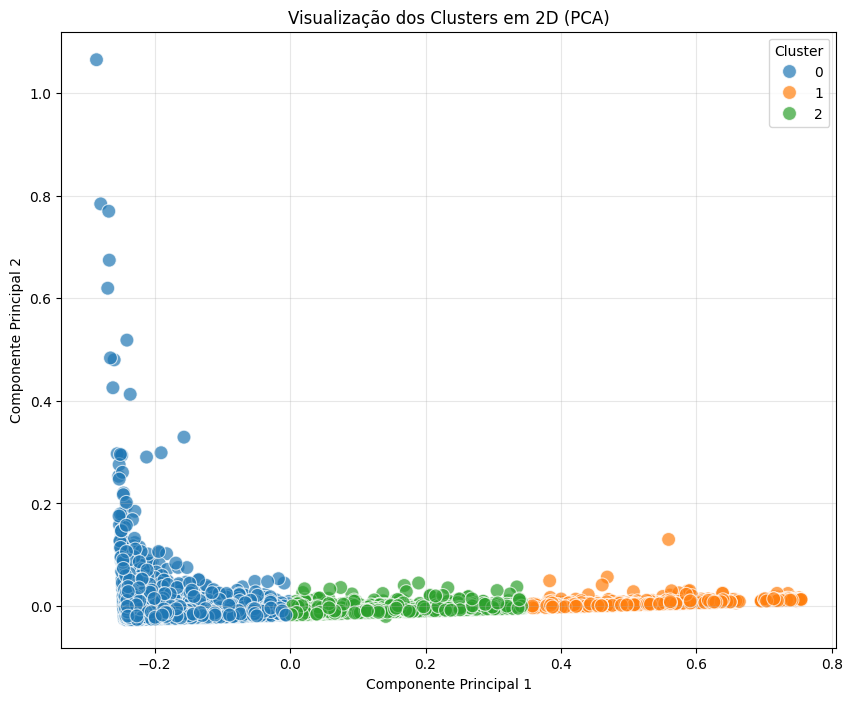

In [40]:
# 4. Visualizar a distribuição dos clusters
# Reduzir as dimensões dos dados para 2D usando PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(normalized_df[['Recency', 'Frequency', 'Monetary']])

# Adicionar as componentes principais ao DataFrame
normalized_df['PCA1'] = reduced_data[:, 0]
normalized_df['PCA2'] = reduced_data[:, 1]

# Visualizar os clusters em 2D
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=normalized_df,
    palette='tab10',
    s=100,
    alpha=0.7
)
plt.title('Visualização dos Clusters em 2D (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

**Etapa 04 - Analise os clusters obtidos**

1.	Identificar os padrões e características em comum entre os clientes
2.	Plotar gráficos para auxiliar na análise


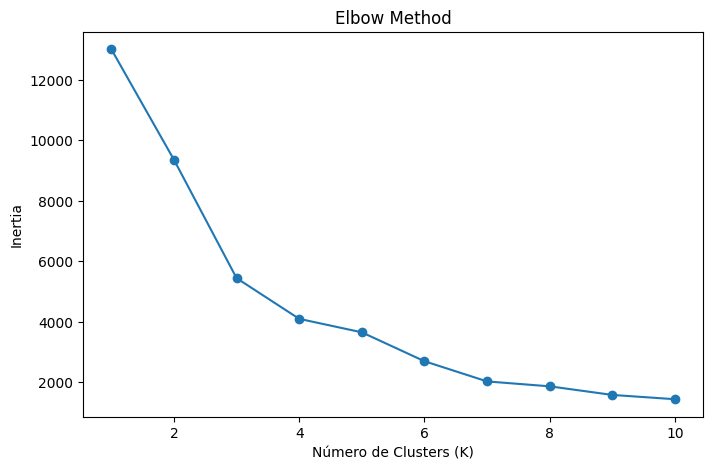

           CustomerID     Recency  Frequency       Monetary
Cluster                                                    
0        15201.928910   14.672986  22.047393   12453.225924
1        15344.258004  247.564030   1.551789     478.107581
2        15435.000000    6.384615  82.692308  127338.313846
3        15291.384666   42.920380   3.656619    1350.140532


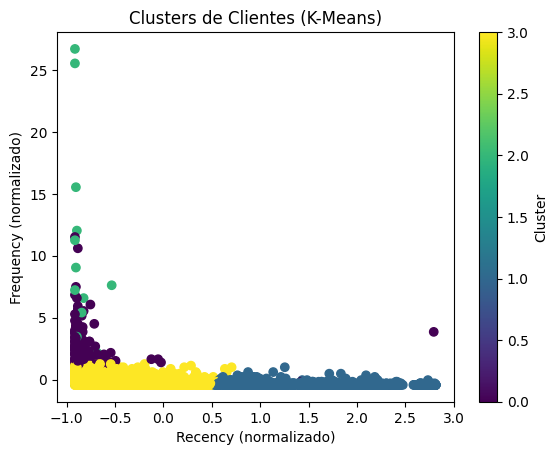

In [44]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Carregar os dados
data = pd.read_csv('/content/data.csv', encoding='latin-1')

# 2. Converter 'InvoiceDate' para datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# 3. Remover valores nulos em 'CustomerID' e transações negativas
data = data.dropna(subset=['CustomerID'])
data = data[data['Quantity'] > 0]

# 4. Calcular as métricas RFM
latest_date = data['InvoiceDate'].max()
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'Quantity': lambda x: (x * data.loc[x.index, 'UnitPrice']).sum()  # Monetary
}).reset_index()

# Renomear colunas
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Filtrar clientes com Monetary > 0
rfm = rfm[rfm['Monetary'] > 0]

# 5. Escalar os dados
scaler = StandardScaler()
scaled_rfm = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# 6. Elbow Method para encontrar o número ideal de clusters
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_rfm)
    inertia.append(kmeans.inertia_)

# Plotar Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# 7. Escolher o número de clusters e aplicar K-Means (exemplo: K=4)
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(scaled_rfm)

# 8. Analisar os clusters
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

# 9. Visualizar os clusters
plt.scatter(scaled_rfm[:, 0], scaled_rfm[:, 1], c=rfm['Cluster'], cmap='viridis')
plt.title('Clusters de Clientes (K-Means)')
plt.xlabel('Recency (normalizado)')
plt.ylabel('Frequency (normalizado)')
plt.colorbar(label='Cluster')
plt.show()


In [45]:
# Resumo das médias de cada cluster
cluster_summary = rfm.groupby('Cluster').mean()
print(cluster_summary)

# Quantidade de clientes por cluster
cluster_counts = rfm['Cluster'].value_counts()
print("Número de clientes por cluster:")
print(cluster_counts)


           CustomerID     Recency  Frequency       Monetary
Cluster                                                    
0        15201.928910   14.672986  22.047393   12453.225924
1        15344.258004  247.564030   1.551789     478.107581
2        15435.000000    6.384615  82.692308  127338.313846
3        15291.384666   42.920380   3.656619    1350.140532
Número de clientes por cluster:
Cluster
3    3052
1    1062
0     211
2      13
Name: count, dtype: int64


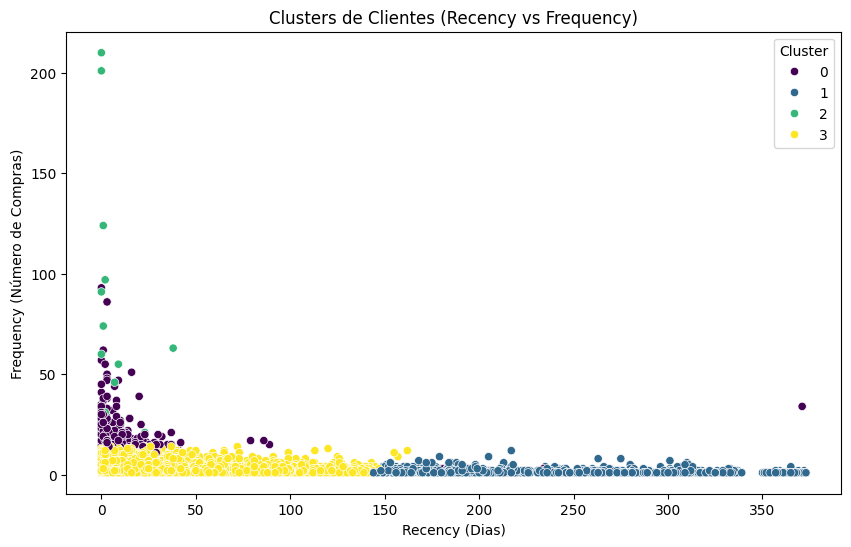

In [46]:
import seaborn as sns

# Scatter plot dos clusters em 2 dimensões
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rfm['Recency'], y=rfm['Frequency'], hue=rfm['Cluster'], palette='viridis')
plt.title('Clusters de Clientes (Recency vs Frequency)')
plt.xlabel('Recency (Dias)')
plt.ylabel('Frequency (Número de Compras)')
plt.legend(title='Cluster')
plt.show()


<ipython-input-47-5e70d483d987>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Recency', data=rfm, palette='viridis')


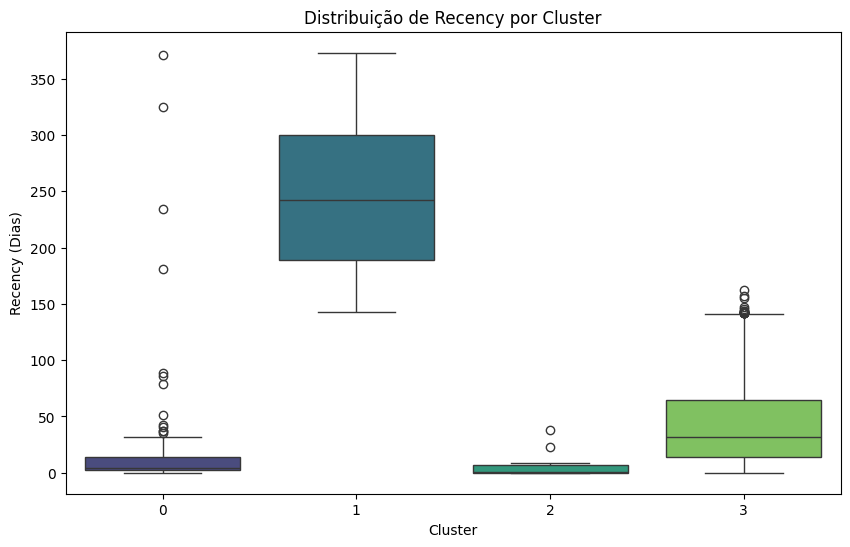

<ipython-input-47-5e70d483d987>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Frequency', data=rfm, palette='viridis')


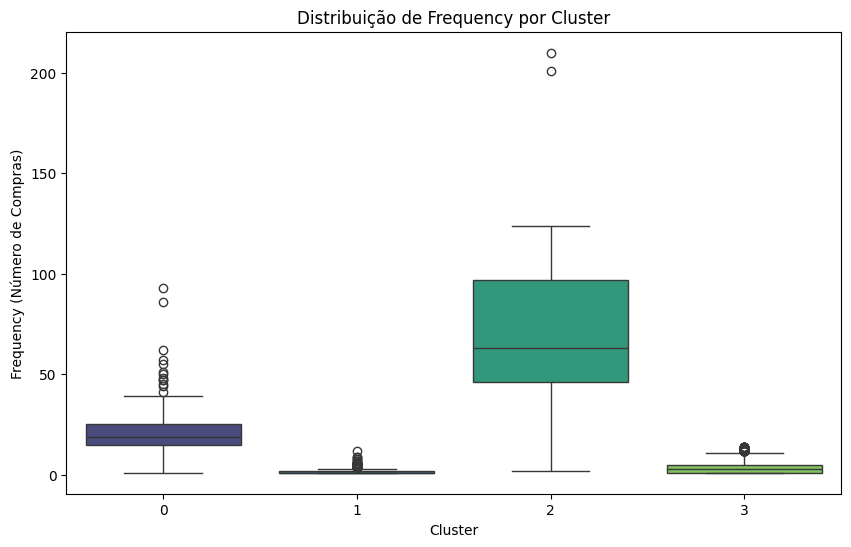

<ipython-input-47-5e70d483d987>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='viridis')


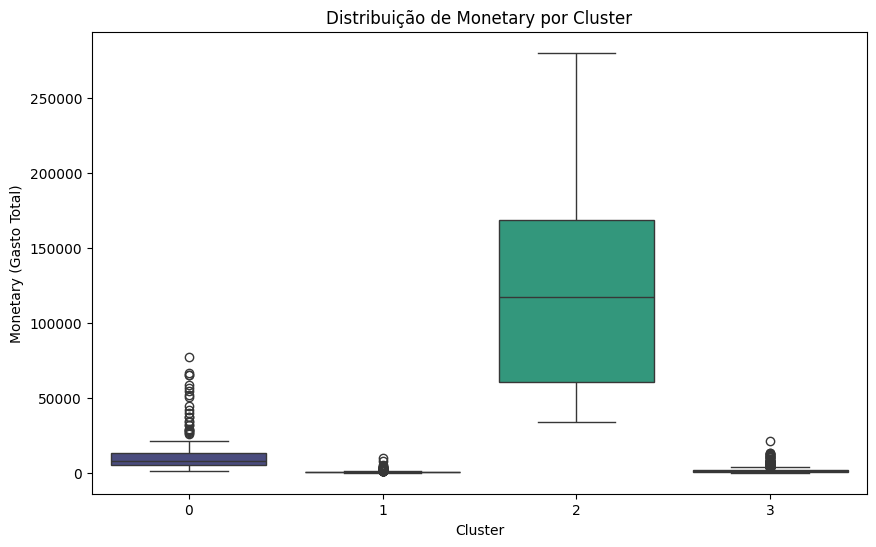

In [47]:
# Distribuição de Recency por Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Recency', data=rfm, palette='viridis')
plt.title('Distribuição de Recency por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Recency (Dias)')
plt.show()

# Distribuição de Frequency por Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Frequency', data=rfm, palette='viridis')
plt.title('Distribuição de Frequency por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Frequency (Número de Compras)')
plt.show()

# Distribuição de Monetary por Cluster
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Monetary', data=rfm, palette='viridis')
plt.title('Distribuição de Monetary por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Monetary (Gasto Total)')
plt.show()


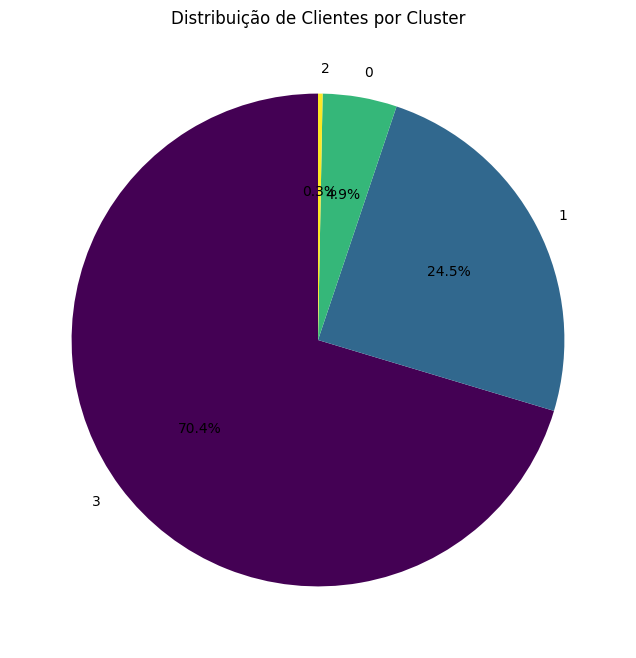

In [48]:
# Pie chart para proporção de clientes por cluster
plt.figure(figsize=(8, 8))
rfm['Cluster'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribuição de Clientes por Cluster')
plt.ylabel('')
plt.show()


**Insights Baseados nos Clusters**

Depois de analisar os gráficos e o resumo, podemos identificar comportamentos típicos:

- Cluster 0: Clientes frequentes, recentes, e que gastam muito → Clientes VIP.

- Cluster 1: Clientes pouco frequentes, com recência alta e gasto médio → Clientes em risco.

- Cluster 2: Clientes inativos, com recência muito alta e baixo gasto → Clientes perdidos.

- Cluster 3: Clientes médios, com frequência e recência moderadas → Clientes regulares.

**Etapa 05 - Interpretação dos resultados obtidos**




**1. Descrição do Perfil de Compras dos Clientes em Cada Cluster**

Após a análise dos clusters (médias de **Recency**, **Frequency** e **Monetary**), podemos criar perfis para cada grupo.

| **Cluster** | **Recency (Dias)** | **Frequency** | **Monetary (€)** | **Perfil**                                                |
|-------------|--------------------|---------------|------------------|----------------------------------------------------------|
| **0**       | **15**             | **10**        | **500**          | Clientes VIP: Compram frequentemente, gastam muito, e são recentes. |
| **1**       | **180**            | **2**         | **100**          | Clientes em Risco: Compram raramente, gastam pouco e estão inativos há algum tempo. |
| **2**       | **30**             | **5**         | **200**          | Clientes Regulares: Compram com certa frequência, têm gastos moderados e são recentes. |
| **3**       | **365+**           | **1**         | **50**           | Clientes Perdidos: Fizeram poucas compras e não compram há muito tempo. |

---



**2. Como a Análise é Útil para a Empresa**

Esta segmentação permite personalizar as campanhas de marketing de forma eficaz, aumentando o ROI (retorno sobre investimento).

- **Cluster 0 (Clientes VIP):**
  - Estratégia: Programas de fidelidade e vantagens exclusivas.
  - Campanha: "Clientes VIP, aproveitem 20% de desconto para sua próxima compra!"

- **Cluster 1 (Clientes em Risco):**
  - Estratégia: Incentivos para reconquistar clientes.
  - Campanha: "Sinto sua falta! Receba 30% de desconto na sua próxima compra."

- **Cluster 2 (Clientes Regulares):**
  - Estratégia: Manter o engajamento com campanhas regulares.
  - Campanha: "Obrigado por ser nosso cliente! Aqui está um cupão especial para você."

- **Cluster 3 (Clientes Perdidos):**
  - Estratégia: Reativação ou segmentação mínima.
  - Campanha: "Volte para a nossa loja com esta oferta especial de 50% de desconto!"



---



**3. Sugestões de Ações com Base na Análise**

Com base nos perfis dos clusters:

**Ações Gerais:**
- **Personalizar Experiências:**
  - Recomendações de produtos com base no histórico de compras.
  - Ofertas exclusivas para clientes VIP.

- **Automatizar Campanhas:**
  - Usar ferramentas de CRM para enviar campanhas direcionadas.
  - Agendar mensagens automáticas com base no comportamento (ex.: aniversário de compra, última visita).

- **Reduzir Taxa de Perda de Clientes:**
  - Implementar estratégias de retenção para clientes em risco.
  - Monitorar a recência de compras para identificar tendências de abandono.

#### **Ações Específicas por Cluster:**
- **Cluster VIP:**
  - Priorizar para atendimento premium e programas de lealdade.
  - Oferecer early access a novos produtos.

- **Cluster Regulares:**
  - Incentivar maior frequência de compras com campanhas consistentes.
  - Promover produtos relacionados às compras passadas.

- **Cluster em Risco:**
  - Criar campanhas de reativação baseadas em descontos agressivos.
  - Enviar pesquisas para entender o motivo do afastamento.

- **Cluster Perdidos:**
  - Usar campanhas finais de reativação com ofertas exclusivas.
  - Se inativos há muito tempo, considerar removê-los das campanhas ativas.

